# Bogota - Noise Data Analysis

This notebook visualises the Bogota diurnal noise map (ogota_totaldiurnoord.geojson).  
The dataset contains **11 MultiPolygon noise zones** classified by dB(A).

In [1]:
import os
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

## Load noise data

In [2]:
_p = os.path.join(os.path.dirname(os.path.abspath(os.getcwd())), 'layers', 'bogota_totaldiurnoord.geojson')
print('Loading from:', _p)

noise = gpd.read_file(_p)
print('CRS:', noise.crs)
print('Shape:', noise.shape)

Loading from: c:\Users\giofo\Desktop\ARCHIVIO\MASTERS\MACAD\2_MACAD\0_MACAD DRIVE\AIA\DATA ENCODING -- SUBMISSIONS\ML-Noise-Prediction\deployment\Bogotà\layers\bogota_totaldiurnoord.geojson
CRS: EPSG:4686
Shape: (11, 9)


In [3]:
noise['db_lo_num'] = noise['db_lo'].astype(float)
noise['db_hi_num'] = noise['db_hi'].astype(float).clip(upper=80)
noise['db_mid'] = (noise['db_lo_num'] + noise['db_hi_num']) / 2

noise_proj = noise.to_crs('EPSG:3116')
noise_proj['area_km2'] = noise_proj.geometry.area / 1e6
noise_proj = noise_proj.sort_values('db_lo_num').reset_index(drop=True)

print(noise_proj[['ruleid','rango','db_lo','db_hi','db_mid','area_km2']].to_string())

    ruleid      rango db_lo db_hi  db_mid    area_km2
0        1       < 35     0    35    17.5  147.981448
1        2  35.1 a 40    35    40    37.5   44.973145
2        3  40.1 a 45    40    45    42.5   35.962467
3        4  45.1 a 50    45    50    47.5   52.823265
4        5  50.1 a 55    50    55    52.5   73.692695
5        6  55.1 a 60    55    60    57.5   54.742431
6        7  60.1 a 65    60    65    62.5   54.305138
7        8  65.1 a 70    65    70    67.5   61.519870
8        9  70.1 a 75    70    75    72.5   41.157687
9       10  75.1 a 80    75    80    77.5   17.616169
10      11       80 >    80   150    80.0   12.512022


## Interactive map

In [4]:
# noise_proj.explore(
#     column='db_mid', cmap='coolwarm', legend=True,
#     tooltip=['rango','db_lo','db_hi'], popup=True,
#     tiles='CartoDB positron',
#     legend_kwds={'caption': 'Noise level dB(A)'}
# )

## Static map - noise zones

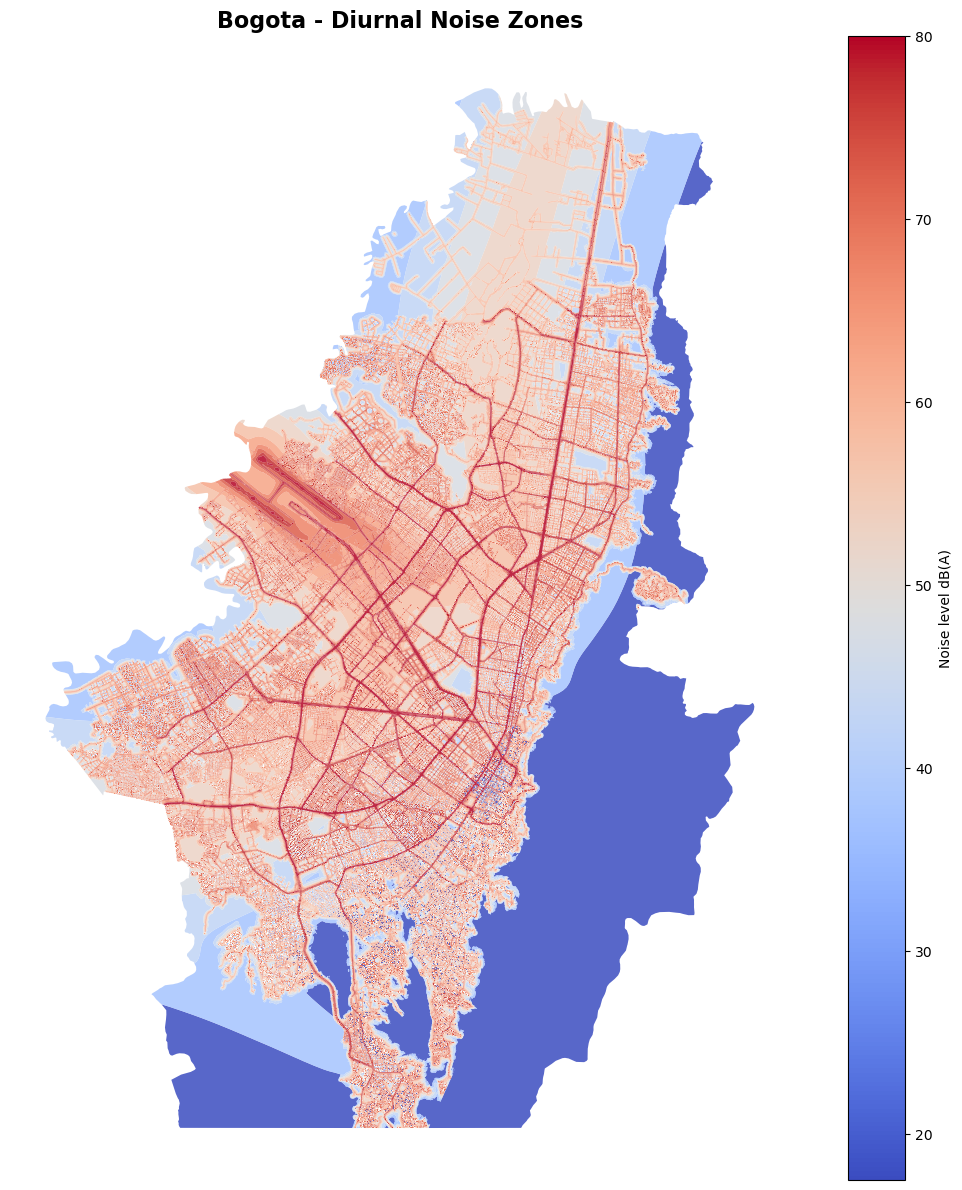

In [5]:
cmap = plt.cm.coolwarm
norm = mcolors.Normalize(vmin=noise_proj['db_mid'].min(), vmax=noise_proj['db_mid'].max())

fig, ax = plt.subplots(figsize=(12, 12))
noise_proj.plot(
    column='db_mid', cmap=cmap, norm=norm, legend=True,
    legend_kwds={'label': 'Noise level dB(A)', 'orientation': 'vertical'},
    ax=ax, edgecolor='none', alpha=0.85
)
ax.set_title('Bogota - Diurnal Noise Zones', fontsize=16, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Area distribution by noise class

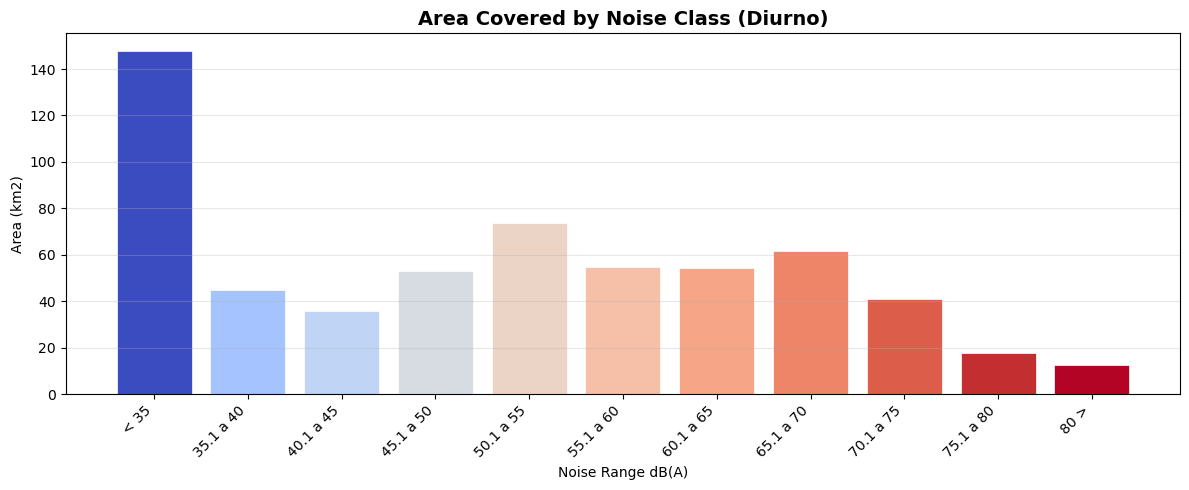

    rango   area_km2
     < 35 147.981448
35.1 a 40  44.973145
40.1 a 45  35.962467
45.1 a 50  52.823265
50.1 a 55  73.692695
55.1 a 60  54.742431
60.1 a 65  54.305138
65.1 a 70  61.519870
70.1 a 75  41.157687
75.1 a 80  17.616169
     80 >  12.512022


In [6]:
colours = cmap(norm(noise_proj['db_mid'].values))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(noise_proj['rango'], noise_proj['area_km2'], color=colours, edgecolor='white', linewidth=0.5)
ax.set_title('Area Covered by Noise Class (Diurno)', fontsize=14, fontweight='bold')
ax.set_xlabel('Noise Range dB(A)')
ax.set_ylabel('Area (km2)')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(noise_proj[['rango','area_km2']].to_string(index=False))

## Cumulative area by noise threshold

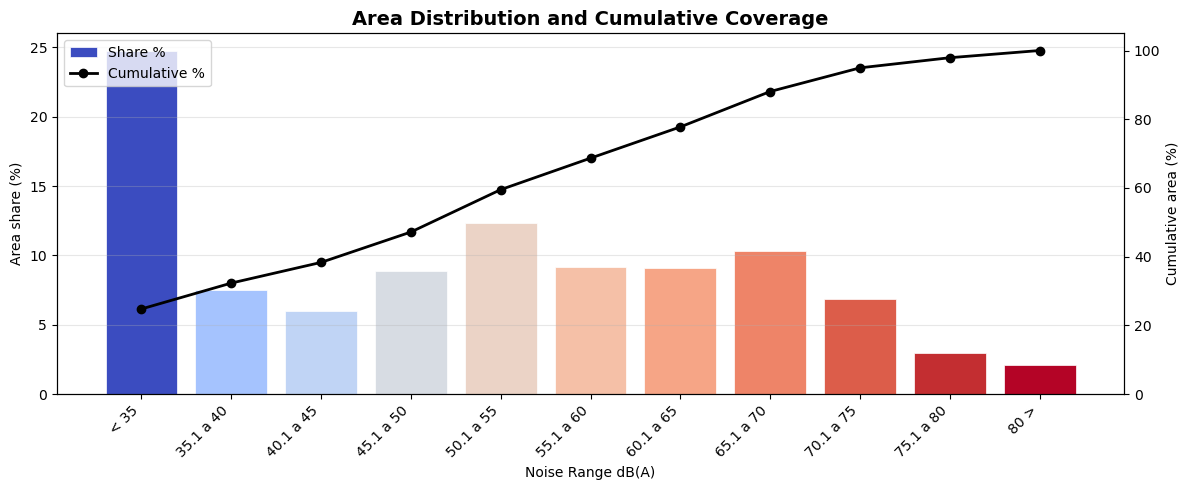

In [7]:
total_area = noise_proj['area_km2'].sum()
noise_proj['area_pct'] = noise_proj['area_km2'] / total_area * 100
noise_proj['cumulative_pct'] = noise_proj['area_pct'].cumsum()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(noise_proj['rango'], noise_proj['area_pct'], color=colours, edgecolor='white', linewidth=0.5, label='Share %')
ax1.set_ylabel('Area share (%)')
ax1.set_xlabel('Noise Range dB(A)')
ax1.set_title('Area Distribution and Cumulative Coverage', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(noise_proj['rango'], noise_proj['cumulative_pct'], color='black', marker='o', linewidth=2, label='Cumulative %')
ax2.set_ylabel('Cumulative area (%)')
ax2.set_ylim(0, 105)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()

## Summary statistics

In [8]:
total_km2 = noise_proj['area_km2'].sum()
dominant = noise_proj.loc[noise_proj['area_km2'].idxmax()]
weighted_avg = (noise_proj['db_mid'] * noise_proj['area_km2']).sum() / total_km2

print(f'Total mapped area : {total_km2:.1f} km2')
print(f'Area-weighted avg : {weighted_avg:.1f} dB(A)')
print()
print(noise_proj[['rango','area_km2','area_pct','cumulative_pct']].to_string(index=False))

Total mapped area : 597.3 km2
Area-weighted avg : 47.3 dB(A)

    rango   area_km2  area_pct  cumulative_pct
     < 35 147.981448 24.775629       24.775629
35.1 a 40  44.973145  7.529579       32.305208
40.1 a 45  35.962467  6.020976       38.326184
45.1 a 50  52.823265  8.843876       47.170060
50.1 a 55  73.692695 12.337917       59.507978
55.1 a 60  54.742431  9.165191       68.673168
60.1 a 65  54.305138  9.091977       77.765146
65.1 a 70  61.519870 10.299896       88.065041
70.1 a 75  41.157687  6.890780       94.955821
75.1 a 80  17.616169  2.949368       97.905189
     80 >  12.512022  2.094811      100.000000
